# Algorithme de Grover

La source principale pour cet algorithme est le livre *Quantum* d'Arnaud Bodin (édition Exo7).
Le code et l'explication qui le précède à été rédigée par moi-même en reprenant les notations et certaines explications.

On s'intéresse au problème de la recherche d'un élément $k_0$ d'une liste non triée de taille $N = 2^n$.

**Modélisation :** on représente les $N$ éléments par les éléments de $\mathbb{Z}/n\mathbb{Z}$.

Pour $k \in \mathbb{Z}/n\mathbb{Z}$, le n-qubit associé à l'écriture binaire de $k$ est $|\underline{k}\rangle$ (ex. pour $N=8$, $|\underline{1}\rangle = |0,0,1\rangle$).

**Oracle :** On suppose avoir une fonction $f : \mathbb{Z}/n\mathbb{Z}\ -> \mathbb{Z}/2\mathbb{Z}$ telle que pour un élément $k_0 \in \mathbb{Z}/n\mathbb{Z}$ (censé être l'élement que l'on cherche dans la liste non triée) on a $f(k_0)=1$ et $f(k)=0$ pour $k$ différent de $k_0$. L'oracle est alors une fonction $F: \mathbb{Z}/n\mathbb{Z} \times \mathbb{Z}/2\mathbb{Z} \ ->  \mathbb{Z}/n\mathbb{Z} \times \mathbb{Z}/2\mathbb{Z}$ telle que $F(x,y)=(x,y+f(x))$ où $+$ est l'addition sur $\mathbb{Z}/n\mathbb{Z}$. On étend cette définition sur les $(n+1)$-qubit

**Notations d'informatique quantique :** On note $H$ la porte de Hadamard qui réalise l'opération linéaire telle que appliquée à un qubit élémentaire renvoie : $H(|1\rangle)=\frac{1}{\sqrt 2}(|0\rangle-|1\rangle)$ et $H(|0\rangle)=\frac{1}{\sqrt 2}(|0\rangle+|1\rangle)$.$\\$
On note pour k entier $H_k$ la porte de Hadamard généralisée à un $k$-qubit, c'est à dire l'opération linéaire de l'application d'une porte de Hadamard sur chacun des $1$-qubits qui composent le $k$-qubit d'entrée : pour $i$ entier tel que $0\leq i \leq 2^k$, $H_k(|\underline{i}\rangle)= H_k(|i_1,...,i_k\rangle)= |H(i_1),...,H(i_k)\rangle$

On note $X$ la porte qui réalise l'opération linéaire telle que appliquée à un qubit élémentaire renvoie : $X(|0\rangle)=|1\rangle$ et $X(|1\rangle)=|0\rangle$

On note $Z$ la porte qui réalise l'opération linéaire telle que appliquée à un qubit élémentaire renvoie : $Z(|0\rangle)=|0\rangle$ et $Z(|1\rangle)=-|1\rangle$

On note $CZ$ (Controlled $Z$) la porte qui réalise l'opération linéaire telle que appliquée à un 2-qubit élémentaire renvoie : $CZ(|\underline{3}\rangle)=-|\underline{3}\rangle$ et $CZ(|\underline{k}\rangle)=|\underline{3}\rangle$, pour $k\neq3$

On peut généraliser cette porte à $C^p Z$ , pour $p\in \mathbb{N}^*$.

**Fondemenent de l'algorithme :** $\newline$
On applique l'oracle sur le $(n+1)$-qubit $|\underline{k}\rangle \otimes H(|1\rangle)$. On remarque que le résultat sur le dernier qubit est $(-1)^{f(k)}\frac{1}{\sqrt 2}(|0\rangle-|1\rangle)$ $\\$ Cet oracle, permet donc de réaliser une réflexion dans l'espace $\prod_{i=1}^{n}\mathbb{H}_i$ parallèlement à $\mathbb{H}_{k_0}$ (en ne retenant que les n premiers qubits de sortie)$\\$
$\\$
Ainsi en prenant en entrée le $(n+1)$-qubit $$\begin{split}
|\psi \rangle = H_{n+1}(|\underline 0\rangle \otimes |1\rangle)&=\frac{1}{\sqrt N}\sum_{i=1}^{N} |\underline{i}\rangle \otimes H(|1\rangle) \ \ \ \ \ \ \ \small (\text{par réccurence sur }n) \normalsize
\end{split}$$ 
On obtient après l'oracle $$\begin{split} 
F(|\psi \rangle)&=\frac{1}{\sqrt N}\sum_{i=1}^{N}  (-1)^{f(k)}\frac{1}{\sqrt 2}|\underline{i}\rangle \otimes(|0\rangle-|1\rangle)\\
&=\frac{1}{\sqrt{N}}(|\underline{0}\rangle+|\underline{1}\rangle+...-|\underline{k_0}\rangle+...+|\underline{N-1}\rangle)\otimes(H(|1\rangle)\\
&=|\psi \rangle -\frac{2}{\sqrt{N}}|\underline{k_0}\rangle\otimes(H(|1\rangle)
\end{split}$$

L'idée est ensuite d'appliquer la symétrie par rapport à $\mathbb{H}_{\psi}$ : $S_\psi= 2|\psi\rangle \langle\psi|-I_{n+1}$

Le résultat final est alors en notant $G=S_\psi \circ F$ l'opérateur de Grover : $$\begin{split}
G(|\psi \rangle)&=S_\psi(F(|\psi \rangle))\\
&=(2|\psi\rangle \langle\psi|-I_{n+1})(|\psi \rangle -\frac{2}{\sqrt{N}}|\underline{k_0}\rangle\otimes H(|1\rangle))\\
&=|\psi\rangle - \frac{4}{\sqrt{N}} \langle\psi |\underline{k_0}\rangle\otimes H(|1\rangle)|\psi\rangle + \frac{2}{\sqrt{N}}|\underline{k_0}\rangle\otimes H(|1\rangle)\\
&=|\psi\rangle - \frac{4}{N}|\psi\rangle + \frac{2}{\sqrt{N}}|\underline{k_0}\rangle\otimes H(|1\rangle)\\
&=(1-\frac{4}{N})|\psi\rangle+ \frac{2}{\sqrt{N}}|\underline{k_0}\rangle\otimes H(|1\rangle) 
\end{split}$$

On peut alors vérifier que l'on a augmenté par ces transformations la probabilité de mesurer $k_0$ :

$$P^{(0)}=|\langle\underline{k_0}\otimes H(\langle1|)|\psi\rangle |^2 = 1/N$$
$$\begin{split}
P^{(1)}&=|\langle\underline{k_0}|\otimes H(\langle1|)G(|\psi \rangle) |^2\\
&=|(1-\frac{4}{N})\langle\underline{k_0}|\otimes H(\langle1|)|\psi\rangle+ \frac{2}{\sqrt{N}}|^2\\
&=|(1-\frac{4}{N})\frac{1}{\sqrt{N}}+ \frac{2}{\sqrt{N}}|^2\\
&=\frac{1}{N}|3-\frac{4}{N}|^2\\
&\approx\frac{3}{N} \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \ \  \small (\text{Si } N \gg 1) \normalsize

\end{split}$$

On peut alors s'interesser à ce qu'il se passe dans le cas de plusieurs transformations de Grover appliquées les unes après les autres.

Pour cela on calcule : $$\begin{split}G(|\underline{k_0}\rangle\otimes H(|1\rangle))) &= -S_\psi(|\underline{k_0}\rangle\otimes H(|1\rangle))\\
&=-(2|\psi\rangle \langle\psi|-I_{n+1})|\underline{k_0}\rangle\otimes H(|1\rangle)\\
&=-\frac{2}{\sqrt{N}}|\psi\rangle + |\underline{k_0}\rangle\otimes H(|1\rangle)
\end{split}$$

Ainsi, considérons un problème qui trouvera tout son intérêt dans la suite :
Soit N un entier et soient deux vecteurs a,b non collinéaires d'un espace de dimension 2 et une application linéaire tels que $G(a)=(1-\frac{4}{N})a+\frac{2}{\sqrt{N})}b$  et $G(b)= -\frac{2}{\sqrt N}a+b$.

Les valeurs propres de $G$ sont alors les $\lambda_\pm=1-\frac{2}{N}\mp i\frac{2}{\sqrt N}\sqrt{1-\frac{1}{4N}}= e^{i\theta}\\$ et $\theta=arcos(1-\frac{2}{N})$ et $sin(\theta)=\frac{2}{\sqrt N}\sqrt{1-\frac{1}{4N}}$ donc  $\\$

Ainsi G est exactement une rotation d'angle $\theta$, et on peut montrer que pour tout $p\in \mathbb{N}$, $$\begin{split}G^p(a)=[cos(p\theta)-\frac{2}{N}\frac{sin(p\theta)}{sin(\theta)}]a +\frac{2}{\sqrt{N}}\frac{sin(p\theta)}{sin(\theta)}b \\
\end{split}$$

Ainsi pour revenir à notre problème, on peut réécrire pour tout $p\in \mathbb{N}$ :$$G^p(|\psi \rangle) = [cos(p\theta)-\frac{4}{N}\frac{sin(p\theta)}{sin(\theta)}]|\psi \rangle +\frac{2}{\sqrt{N}}\frac{sin(p\theta)}{sin(\theta)}|\underline{k_0}\rangle\otimes H(|1\rangle))$$
On peut donc calculer
$$\begin{split}
P^{(p)}&= \frac{1}{N}|[cos(p\theta)-\frac{4}{N}\frac{sin(p\theta)}{sin(\theta)}] +\frac{2sin(p\theta)}{sin(\theta)}|^2\\
&=\frac{1}{N}|cos(p\theta)+(2-\frac{4}{N})\frac{sin(p\theta)}{sin(\theta)}|^2
\end{split}$$

In [1]:
pip install numpy scipy matplotlib ipykernel

Note: you may need to restart the kernel to use updated packages.


p_max: 17.77, P(p_max): 0.9941


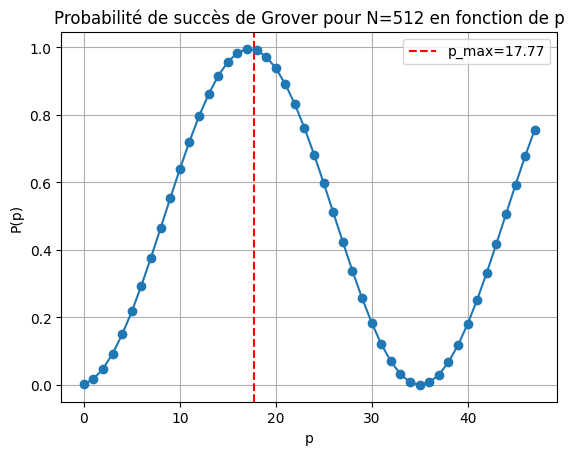

In [2]:
import numpy as np
import matplotlib.pyplot as plt

N = 2 ** 9  # Nombre d'éléments dans la base de données (doit être une puissance de 2)
theta = np.arccos(1 - 2 / N)
p_max=  np.pi / 4 *np.sqrt(N) #c'est le p supposé être une bonne approximation permettant de maximiser la probabilité de succès
def P(p):
     return (np.cos(p * theta) + (2 - 4 / N) * np.sin(p * theta) / np.sin(theta)) ** 2 / N

p = np.arange(0, 2.7*p_max, 1)
P_val=P(p)
print(f"p_max: {p_max:.2f}, P(p_max): {P(p_max):.4f}")
plt.axvline(x=p_max, color='r', linestyle='--', label=f'p_max={p_max:.2f}')
plt.plot(p, P_val, marker='o')
plt.xlabel('p')
plt.ylabel('P(p)')
plt.title(f'Probabilité de succès de Grover pour N={N} en fonction de p')
plt.grid(True)
plt.legend()
plt.show()

On cherche à démontrer que la probabilité de succès maximale p_max de l'algorithme de Grover bien de l'odre de $O(\sqrt N )$, $N$ est le nombre d'éléments dans la base de données.

Par un calcul de dérivées, on montre que $p_{max}$ vérifie : $\ sin(p\theta)=(2-\frac{4}{N})\frac{cos(p\theta)}{sin(\theta)}$

A la limte $N\gg 1$, on trouve avec $sin(\theta)\approx \frac{2}{\sqrt N}$ : $\\
\sin(\theta p)=\sqrt{N} cos(\theta p)$, d'où $\theta p \xrightarrow[N\gg 1]{} \pi / 2$ (on s'intéresse à la première solution seulement).$\\$
Finalement, on retrouve $p_{max}\approx \frac{\pi}{4}\sqrt N$


Text(0.5, 1.0, 'Valeur de p qui maximise la probabilité de succès de Grover en fonction de N')

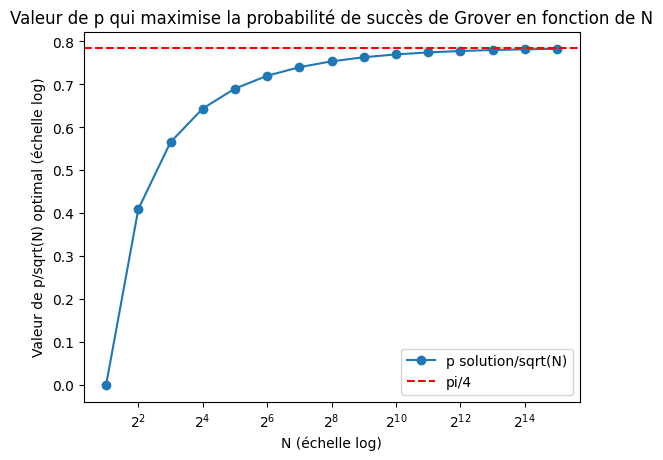

In [3]:
#je cherche à trouver la valeur de p dans [0,p_max] qui vérifie sin(p * theta) = (2-4/N)*cos(p*theta/sin(theta)) en fonction de N.
#On nomme o=p_opt/sqrt(N)
import scipy.optimize as opt
N_var = [2 ** i for i in range(1, 16)]  # N varie de 2^1 à 2^1
o_solutions = []
for N in N_var:
    theta_N = np.arccos(1 - 2 / N)
    def p_max(N):
        return np.pi / 4 * np.sqrt(N) 
    def equation(p):
        return np.sin(p * theta_N) - (2 - 4 / N) * np.cos(p * theta_N) / np.sin(theta_N)
    p_solution = opt.brentq(equation, 0, p_max(N))
    o_solution = p_solution / np.sqrt(N)
    o_solutions.append(o_solution)
plt.plot(N_var, o_solutions, marker='o', label='p solution/sqrt(N)')
plt.axhline(y=np.pi / 4, color='r', linestyle='--', label='pi/4')
plt.xscale('log', base=2)
plt.xlabel('N (échelle log)')
plt.ylabel('Valeur de p/sqrt(N) optimal (échelle log)')
plt.legend()
plt.title('Valeur de p qui maximise la probabilité de succès de Grover en fonction de N')

Ainsi on a bien démontré qu'en supposant que l'oracle fonctionne en une compléxité de l'ordre de $\mathcal{O}(1)$, alors il suffit d'itérer l'opérateur de Grover de l'ordre de $\mathcal{O}(\sqrt N)$ pour maximiser la probabilité d'obtention de l'élément recherché. C'est donc un algorithme probabiliste qui fonctionne avec une complexité $\mathcal{O}(\sqrt N)$.

La difficulté informatiquement réside donc dans le bon choix d'un oracle.

**Implémentation concrète**
Nous utiliserons dans la suite la librairie Qiskit d'IBM.


In [4]:
%pip install pylatexenc
%pip install qiskit qiskit-aer matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [20]:
%pip install dd

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.3/4.3 MB 10.0 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 57.2 MB/s  0:00:00
  Created wheel for ply: filename=ply-3.10-py2.py3-none-any.whl size=48469 sha256=e362ee19dc3f9eb7a639f1cf7c2fec78028e600e39b5e3dfe4d78306b3a5c5bb
  Stored in directory: /home/codespace/.cache/pip/wheels/f2/1a/b8/7ed7951204e2127628e5aa2d8282ef93f7094f68fa7990e16e
  Created wheel for astutils: filename=astutils-0.0.6-py3-none-any.whl size=6619 sha256=853a896a135fd5a3f4359507d82e153ba6825951fc45ece453545a25c4e6878c
  Stored in directory: /home/codespace/.cache/pip/wheels/41/66/d2/dac2e1a9d6b250914b7828534d897873789f576ccdddca10a4
Successfully built ply astutils
   ━

In [1]:
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
from qiskit import ClassicalRegister


circuit quantique simple:
        ┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1 


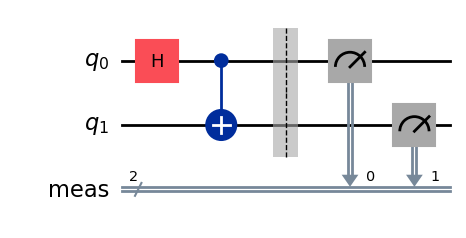

In [2]:
qc = QuantumCircuit(2)

qc.h(0)

qc.cx(0, 1)

qc.measure_all()
print(f"circuit quantique simple:\n{qc}")
qc.draw("mpl")

{'00': 522, '11': 478}


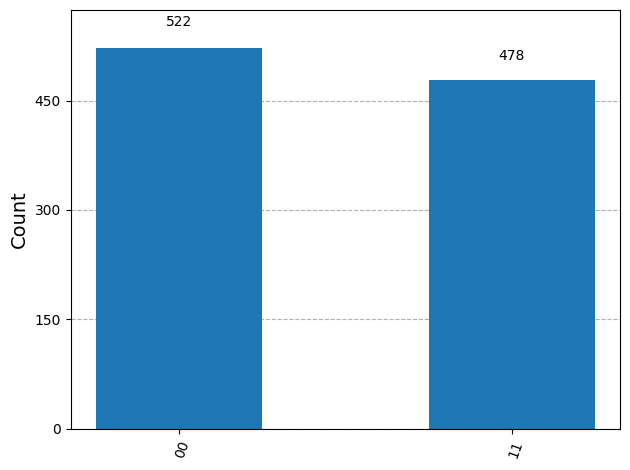

In [3]:
#Exemple de simulation d'un circuit quantique simple
simulator = AerSimulator()

result = simulator.run(qc, shots=1000).result()

counts = result.get_counts()

print(counts)
plot_histogram(counts)

**Première construction de l'oracle :**
On construit l'oracle de sorte à pouvoir se le donner pour chercher l'élément $k_0$.\
Cette construction ne fait pas partie de l'algorithme car on ne sait initialement pas quel est l'élément à chercher. On ne connaît que la focntion qui permet de le trouver.\
On va donc se donner des fonctions de la forme `"(x1 & ~x2 & x3 & x4)"` qui sont des string à convertir en circuit quantique

In [4]:
def binary(x, n):
    """
    Renvoie l'écriture binaire de x sur n bits.
    """
    if x >= 2**n:
        raise ValueError("x ne tient pas sur n bits")

    return format(x, f"0{n}b")

def key_to_formula(key,n):

    bits = binary(key,n)

    terms=[]

    for i,b in enumerate(bits):

        if b=="1":
            terms.append(f"x{i+1}")
        else:
            terms.append(f"~x{i+1}")

    return "("+" & ".join(terms)+")"

In [5]:
print(key_to_formula(11,4))

(x1 & ~x2 & x3 & x4)


In [6]:
#oracle donné
f="(x1 & ~x2 & x3 & x4)"

In [7]:
from qiskit import QuantumCircuit

def build_and_oracle(expr):

    expr = expr.strip("()")

    terms = [t.strip() for t in expr.split("&")]

    n = max(
        int(t.replace("~","").replace("x",""))
        for t in terms
    )

    qc = QuantumCircuit(n+1)

    controls = []

    for term in terms:

        if term.startswith("~"):

            i = int(term[2:]) - 1
            qc.x(i)

        else:

            i = int(term[1:]) - 1

        controls.append(i)
        
    qc.mcx(controls, n)

    for term in terms:

        if term.startswith("~"):

            i = int(term[2:]) - 1
            qc.x(i)
    
    return qc,n

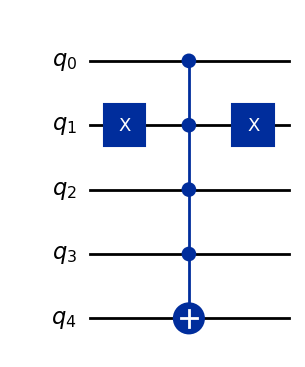

In [8]:
build_oracle=build_and_oracle(f)
oracle=build_oracle[0]
n=build_oracle[1]
oracle_gate = oracle.to_gate(label="oracle")
oracle.draw("mpl")

**Réalisation de $S_\psi$ :**

On remarque que $S_\psi$ est obtenue par changement de référentiel à partir de l'opérateur $S_0$, décrit dans la base canonique par la matrice $diag(1,-1,...,-1)$.

Ainsi, $S_\psi=H_n \circ S_0 \circ H_n^{-1}=H_n \circ S_0 \circ H_n$

Pour consitruire l'opérateur $S_0$ en terme de porte logique nous alllons utiliser des combinaisons des portes $X$ et $C^pZ$.

On remarque que la matrice de la transformation obtenue après avoir appliqué $X$ sur chaque entrée est $\operatorname{antidiag}(1,\ldots,1)$.

Ainsi :

$$
\begin{pmatrix}
0 & 0 & \cdots & 0 & 1\\
0 & \vdots & \cdots & 1 & 0\\
\vdots & 0 & \ddots & 0 & \vdots\\
0 & 1 & \cdots & \vdots & 0\\
1 & 0 & \cdots & 0 & 0
\end{pmatrix}
\begin{pmatrix}
-1 & 0 & \cdots & 0 & 0\\
0 & 1 & 0 & \vdots & 0\\
\vdots & 0 & \ddots & 0 & \vdots\\
0 & \vdots & 0 & \ddots & 0\\
0 & 0 & \cdots & 0 & 1
\end{pmatrix}
\begin{pmatrix}
0 & 0 & \cdots & 0 & 1\\
0 & \vdots & \cdots & 1 & 0\\
\vdots & 0 & \ddots & 0 & \vdots\\
0 & 1 & \cdots & \vdots & 0\\
1 & 0 & \cdots & 0 & 0
\end{pmatrix}
=-S_0
$$

Or une phase globale n'a aucun effet physique donc nous emploierons cette méthode

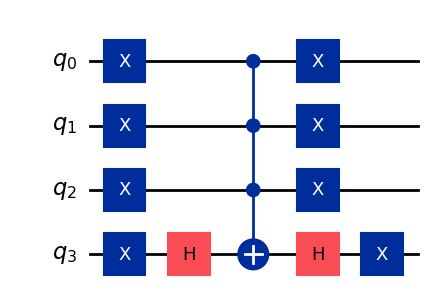

In [9]:
from qiskit import QuantumCircuit
s_0 = QuantumCircuit(n)
# transform |001> -> |111>
for i in range(n):
    s_0.x(i)

# Porte CCZ

s_0.h(n-1)
s_0.mcx(list(range(n-1)), n-1) #porte multi-controlée

s_0.h(n-1)

# on revient dans la base initiale
for i in range(n):
    s_0.x(i)

s0_gate = s_0.to_gate(label="S0")
s_0.draw("mpl")

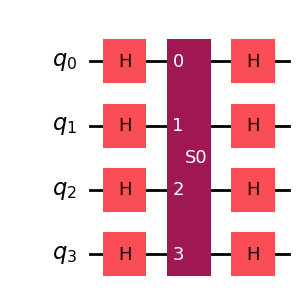

In [10]:
#On réalise maintenant la porte s_psi à partir de s_0 
s_psi = QuantumCircuit(n)
for i in range(n):
    s_psi.h(i)

s_psi.append(s0_gate, list(range(n)))

for i in range(n):
    s_psi.h(i)
    
spsi_gate = s_psi.to_gate(label="Spsi")
s_psi.draw("mpl")

On calcule le nombre d'itération de l'algorithme :

In [11]:
import numpy as np
N=2**n
itérations=int(np.pi/4 * np.sqrt(N))
print(itérations)

3


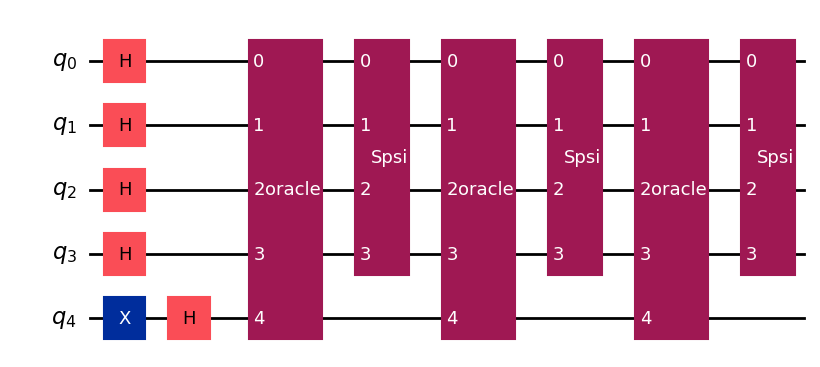

In [12]:
qc = QuantumCircuit(n+1)
qc.x(n)  #passage du dernier qubit à 1
for i in range(n+1):
    qc.h(i)

for i in range(itérations):
    qc.append(oracle_gate, list(range(n+1)))
    qc.append(spsi_gate,list(range(n)))
qc.draw("mpl")

{'1011': 26, '0000': 18, '1101': 9632, '1000': 22, '0110': 29, '0001': 17, '1111': 19, '0011': 20, '0111': 35, '1110': 21, '0010': 30, '1100': 29, '0101': 24, '1001': 18, '0100': 35, '1010': 25}


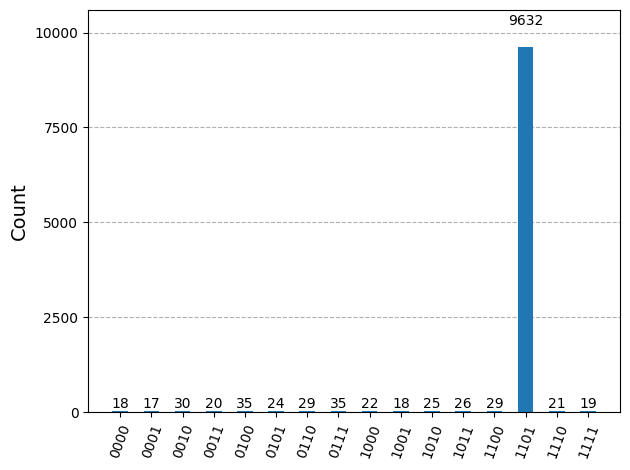

In [13]:
from qiskit import transpile
c = ClassicalRegister(n)

qc.add_register(c)
qc.measure(range(n), range(n))
simulator = AerSimulator()
# Transpile / décomposer les gates personnalisées pour Aer
qc_prepared = transpile(qc, simulator)
result = simulator.run(qc_prepared, shots=10000).result()

counts = result.get_counts()

print(counts)
plot_histogram(counts)

In [14]:
def max_in_dict(data):
    """
    Retourne un tuple (clé, valeur) correspondant à la valeur maximale du dictionnaire.
    Gère les cas de dictionnaire vide.
    """
    if not isinstance(data, dict):
        raise TypeError("L'entrée doit être un dictionnaire.")
    if not data:
        return None 
    max_key = max(data, key=data.get)
    return max_key, data[max_key]
max_in_dict(counts)[0]
def qiskit_to_bits(s):
    """
    Convertit une chaîne Qiskit en liste de bits
    dans l'ordre x1,x2,...,xn.
    """
    res=""
    for c in s :
        res=c+res
    return res

In [15]:
def verifier(f, bits):
    """
    Vérifie si la chaîne de bits satisfait la formule booléenne.

    Exemple :
        verifier("(x1 & ~x2 & x3 & x4)", "1011")
    """

    expr = f

    # Remplace les variables par True/False
    for i, b in enumerate(bits, start=1):
        valeur = "True" if b == "1" else "False"
        expr = expr.replace(f"x{i}", valeur)

    # Remplace les opérateurs
    expr = expr.replace("&", " and ")
    expr = expr.replace("|", " or ")
    expr = expr.replace("~", " not ")

    return eval(expr)

In [16]:
print(verifier(f,qiskit_to_bits(max_in_dict(counts)[0])))

True


**Implémentation avec une structure BDD**

In [25]:
from dd.autoref import BDD

class OracleBDD:

    def __init__(self, n):

        self.n = n

        self.database = {}

        self.bdd = BDD()

        self.vars = [f"x{i+1}" for i in range(n)]

        self.bdd.declare(*self.vars)


    def insert(self, key, value):

        self.database[key] = value


    def build_expression(self, target):

        clauses = []

        for key, value in self.database.items():

            if value != target:
                continue

            bits = format(key, f"0{self.n}b")

            terms = []

            for bit, var in zip(bits, self.vars):

                if bit == "1":
                    terms.append(var)
                else:
                    terms.append("~"+var)

            clauses.append("(" + " & ".join(terms) + ")")

        if len(clauses)==0:
            raise ValueError("Valeur absente")

        expr = " | ".join(clauses)

        self.root = self.bdd.add_expr(expr)

        return expr

In [28]:
dictionnaire = OracleBDD(4)

dictionnaire.insert(3,"A")
dictionnaire.insert(5,"B")
dictionnaire.insert(9,"C")
dictionnaire.insert(12,"D")

In [29]:
expr = dictionnaire.build_expression("C")

print(expr)

(x1 & ~x2 & ~x3 & x4)


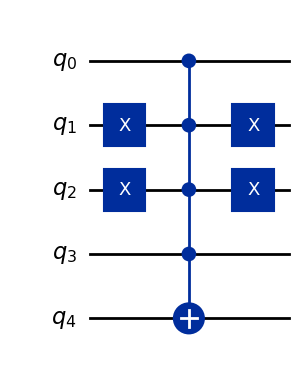

In [30]:
oracle, n = build_and_oracle(expr)

oracle_gate = oracle.to_gate(label="oracle")

oracle.draw("mpl")

**Implémentation directement sans passer pas les conjonctions**

In [36]:
class MTBDDNode:

    def __init__(self,
                 variable=None,
                 low=None,
                 high=None,
                 value=None):

        self.variable = variable      # indice du qubit (0,1,...,n-1)
        self.low = low                # branche x_i = 0
        self.high = high              # branche x_i = 1
        self.value = value            # uniquement pour les feuilles

    @property
    def is_leaf(self):
        return self.variable is None


In [37]:


def build_oracle_from_mtbdd(root, target, n):

    qc = QuantumCircuit(n + 1)

    def recurse(node, controls):

        # -------------------------------
        # Feuille
        # -------------------------------

        if node.is_leaf:

            if node.value == target:

                qc.mcx(controls, n)

            return

        var = node.variable

        # -------------------------------
        # Branche 0
        # -------------------------------

        qc.x(var)

        controls.append(var)

        recurse(node.low, controls)

        controls.pop()

        qc.x(var)

        # -------------------------------
        # Branche 1
        # -------------------------------

        controls.append(var)

        recurse(node.high, controls)

        controls.pop()

    recurse(root, [])

    return qc

Exemple :

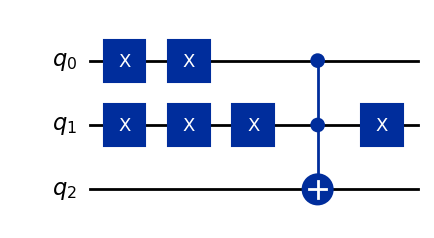

In [38]:
leafA = MTBDDNode(value="A")
leafB = MTBDDNode(value="B")
leafC = MTBDDNode(value="C")
leafD = MTBDDNode(value="D")

left = MTBDDNode(
    variable=1,
    low=leafA,
    high=leafB
)

right = MTBDDNode(
    variable=1,
    low=leafC,
    high=leafD
)

root = MTBDDNode(
    variable=0,
    low=left,
    high=right
)
oracle = build_oracle_from_mtbdd(root, "C", 2)

oracle.draw("mpl")